### 数据导入

In [15]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 插值方法
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import CubicSpline

In [38]:
# 数据导入
# data = pd.read_excel('./High Scenario/高情景_全国2020-2060分行业增加值.xlsx', sheet_name='增加值 (2001-2060, 2020RMB)') # 高情景数据导入,修改文件路径
# data = pd.read_excel('./Low Scenario/低情景_全国2020-2060分行业增加值.xlsx', sheet_name='增加值 (2001-2060, 2020RMB)') # 低情景数据导入,修改文件路径
data = pd.read_excel('./Medium Scenario/中情景_全国2020-2060分行业增加值.xlsx', sheet_name='增加值 (2001-2060, 2020RMB)') # 中情景数据导入,修改文件路径

# 添加index
index_names = data.iloc[:, 0].values # 提取行业名称作为索引。注意提取第一列的值作为索引，而不是第一列。
data = data.iloc[:, 1:].set_index(index_names)

# 提取初始年(2022)、2025、2030、2035、2050、2060年的数据
data_stamp = data[[2022, 2025, 2030, 2035, 2050, 2060]].dropna(axis=0)
data_stamp = data_stamp.loc[~data_stamp.index.duplicated(keep='first')]

#### 数据填充

##### 分段三次样条插值

C:\Users\cjwdl\AppData\Local\Temp\ipykernel_26444\3379012250.py:53: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()  # 调整子图布局


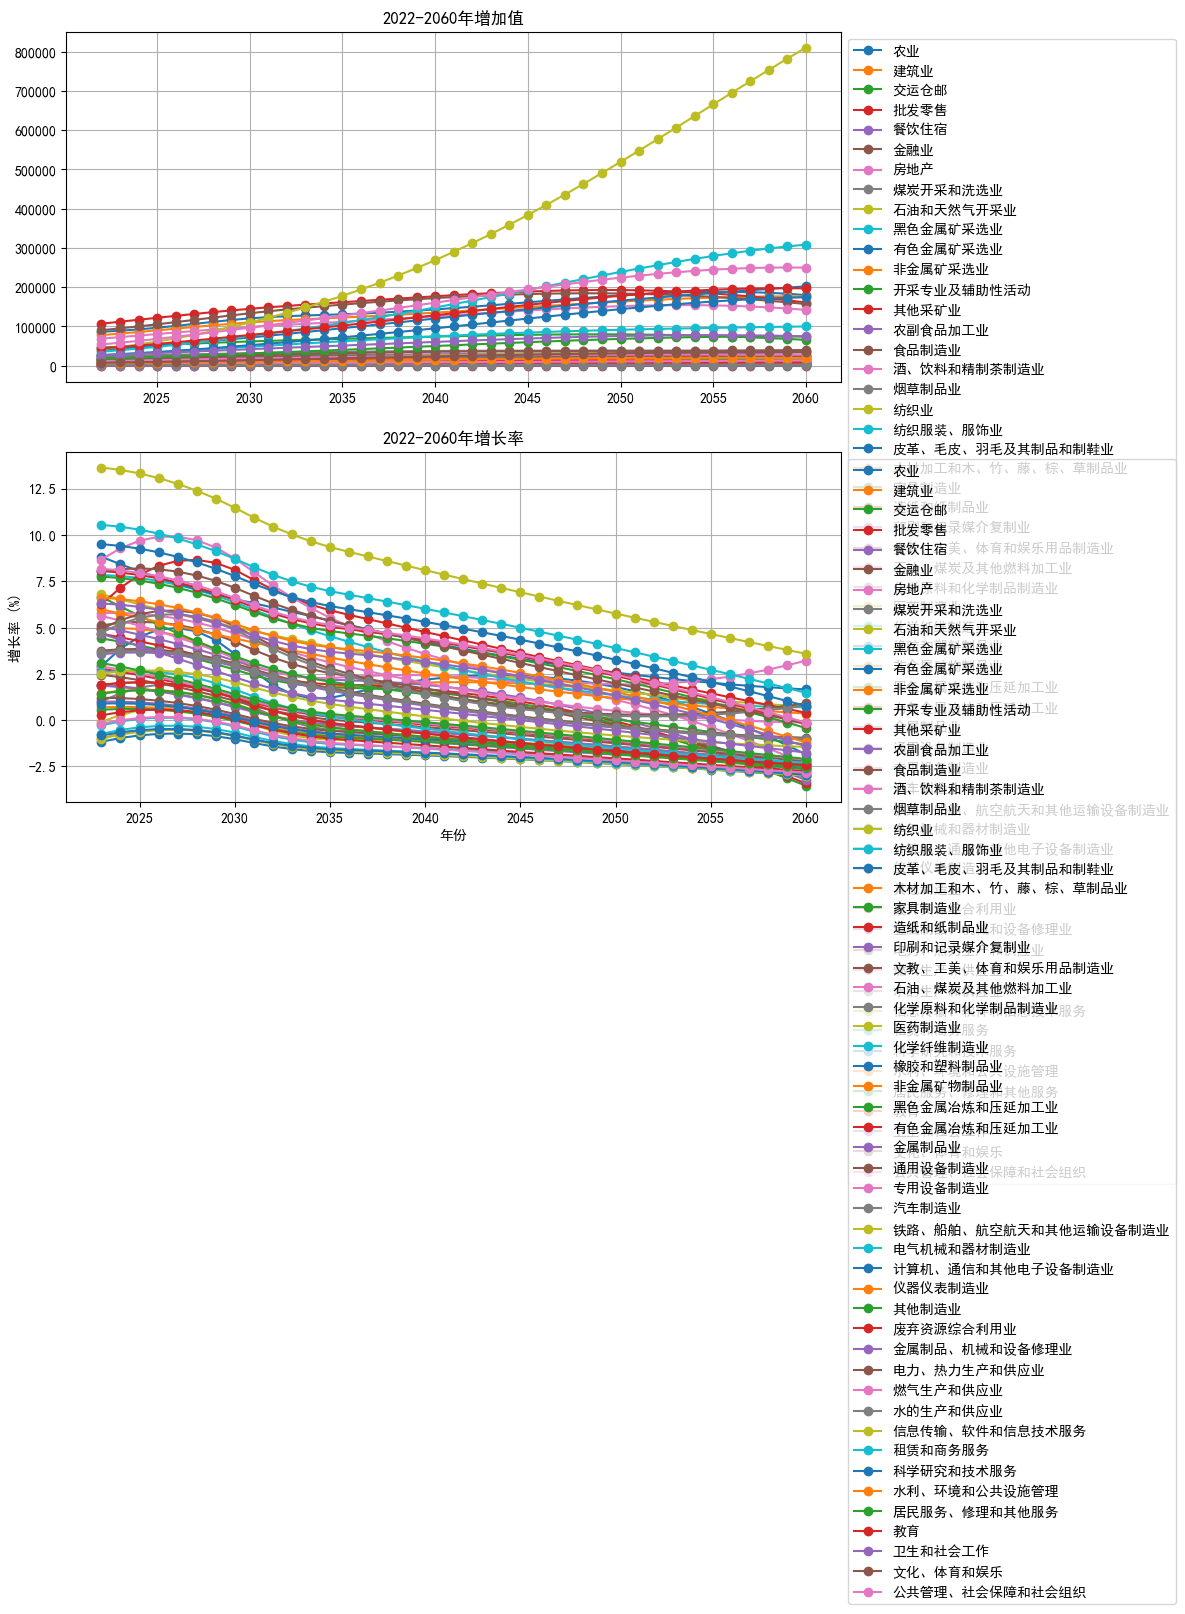

In [39]:
# 农业、建筑业、工业细分行业、除其他三产的服务业插值
data_select = data_stamp.drop(['地区生产总值', '工业', '其他三产', '第三产业'])

# 需要进行插值的年份
original_year = list(range(2023, 2061))  # 初始年+1-2061年
year_to_remove = [2025, 2030, 2035, 2050, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

# 设置平滑因子
smoothing_factor = 0.8  # 调整平滑程度，平滑因子越大数据之间增长率的变化越小
# 接受预测的GDP数据
data_prediction = pd.DataFrame(index=data_select.index, columns=year_to_interpolate, dtype=float)

# 对每一行(行业)进行插值
for industry in data_select.index:
    x = data_select.columns.astype(int)  # 已知年份
    y = np.log(data_select.loc[industry].values)  # 对应行业的对数值
    cs = CubicSpline(x, y, extrapolate=False)  # 创建分段三次样条插值对象
    missing_values = np.exp(cs(year_to_interpolate))  # 计算缺失年份的插值结果
    data_prediction.loc[industry] = missing_values  # 添加到预测值DataFrame中

# 合并预测值DataFrame和原始DataFrame
data_interpolate = pd.concat([data_select, data_prediction], axis=1)

# 将列名转换为整数类型并按年份从小到大排序列
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)


# 图形绘制
data_growth_rate = data_interpolate.pct_change(axis=1) * 100 # 计算增长率

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10)) # 设置画布和子图

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')  # 设置图标题
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax1.grid(True)  # 显示网格线

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')  # 设置图标题
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax2.grid(True)  # 显示网格线
ax2.set_xlabel('年份')  # 设置横轴标签
ax2.set_ylabel('增长率 (%)')  # 设置纵轴标签

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

In [40]:
# 计算工业、其他三产、地区生产总值的值
data_interpolate.loc['工业',:] = data_interpolate.loc['煤炭开采和洗选业':'水的生产和供应业',:].sum()
data_interpolate.loc['其他三产', :] = data_interpolate.loc['信息传输、软件和信息技术服务':'公共管理、社会保障和社会组织', :].sum()
data_interpolate.loc['地区生产总值', :] = data_interpolate.loc['农业':'公共管理、社会保障和社会组织', :].sum()

### 数据导出

In [41]:
# 导出数据
# writer = pd.ExcelWriter('./High Scenario/高情景数据平滑-全国2020-2060增加值.xlsx', engine='xlsxwriter') # 高情景数据导出
# writer = pd.ExcelWriter('./Low Scenario/低情景数据平滑-全国2020-2060增加值.xlsx', engine='xlsxwriter') # 低情景数据导出
writer = pd.ExcelWriter('./Medium Scenario/中情景数据平滑-全国2020-2060增加值.xlsx', engine='xlsxwriter') # 中情景数据导出

data_interpolate.to_excel(writer, index=True)

# 保存Excel文件
writer._save()